# FT-Transformer Prediction Model

### How to add more features: 
To add more features, the following lines must be changed:
- dtype = np.dtype([...]): for each added feature, add ('feature name', datatype)
- data = np.loadtxt(...): usecols=(...) determines what columns (0-indexed) are used for training. Add the column number of the recently-added feature to the end of the list
- emotion_fields = [...]: add 'feature name' to the list

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1.0927 - mean_absolute_error: 0.8331 - val_loss: 0.9357 - val_mean_absolute_error: 0.7989
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9580 - mean_absolute_error: 0.7697 - val_loss: 0.9845 - val_mean_absolute_error: 0.8195
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9793 - mean_absolute_error: 0.7820 - val_loss: 0.9097 - val_mean_absolute_error: 0.7865
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9743 - mean_absolute_error: 0.7715 - val_loss: 0.9386 - val_mean_absolute_error: 0.8041
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9816 - mean_absolute_error: 0.7679 - val_loss: 0.9376 - val_mean_absolute_error: 0.8002
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9691 - mean_absolute_error: 0.7760 - val_loss: 0.9977 - val_mean_absolute_error: 0.8230
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9909 - mean_absolute_error: 0.7915 - val_los

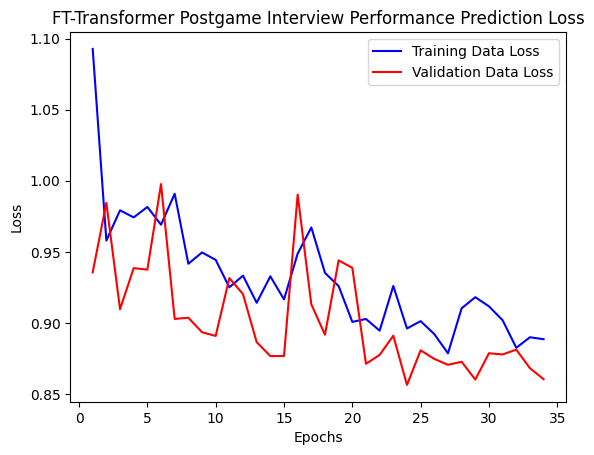

('XLBI4Xst98', 0.166287, 0.000433, 0.09883800000000001, 0.070019, 0.344422, 0.028742999999999998, 0.291258, 0.09262160435333454, 1.4038930270350922, -1.1098778325568897, -1.7264178680649656, -0.4262653504917964)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

data_file = 'emotion_results_final_with_gmsc.csv'
dtype = np.dtype([
    ('id', 'U10'),
    ('avg_angry', float),
    ('avg_disgust', float),
    ('avg_fear', float),
    ('avg_happy', float),
    ('avg_sad', float),
    ('avg_surprise', float),
    ('avg_neutral', float),
    ('days_of_rest', float),
    ('opp_drtg', float),
    ('opp_win_pct', float),
    ('historical_gmsc_avg', float),
    ('next_game_gmsc', float),
])

data = np.loadtxt(
    data_file,
    dtype=dtype,
    delimiter=',',
    skiprows=1,
    usecols=(2, 4, 5, 6, 7, 8, 9, 10, 13, 15, 16, 17, 18),
)

emotion_fields = [
    'avg_angry',
    'avg_disgust',
    'avg_fear',
    'avg_happy',
    'avg_sad',
    'avg_surprise',
    'avg_neutral',
]
for field in emotion_fields:
    data[field] = data[field] / 100.0

# Standardize continuous features
for field in ['days_of_rest', 'opp_drtg', 'opp_win_pct', 'historical_gmsc_avg']:
    data[field] = (data[field] - data[field].mean()) / data[field].std()

data['next_game_gmsc'] = (data['next_game_gmsc'] - data['next_game_gmsc'].mean()) / data['next_game_gmsc'].std()

np.random.shuffle(data)

split_index = int(len(data) * 0.8)
train_data = data[:split_index]
test_data = data[split_index:]

feature_names = data.dtype.names[1:-1]
x_train = np.array([train_data[name] for name in feature_names]).T.astype('float32')
y_train = np.array(train_data['next_game_gmsc']).astype('float32')
x_test = np.array([test_data[name] for name in feature_names]).T.astype('float32')
y_test = np.array(test_data['next_game_gmsc']).astype('float32')

# Standardize features using training split only
feature_mean = x_train.mean(axis=0, keepdims=True)
feature_std = x_train.std(axis=0, keepdims=True) + 1e-8
x_train = (x_train - feature_mean) / feature_std
x_test = (x_test - feature_mean) / feature_std

# FT-Transformer treats each feature as a token
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]


def transformer_block(inputs, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
    attention_input = layers.LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout_rate,
    )(attention_input, attention_input)
    x = layers.Add()([inputs, attention_output])

    ffn_input = layers.LayerNormalization(epsilon=1e-6)(x)
    ffn_output = layers.Dense(ff_dim, activation='relu')(ffn_input)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    ffn_output = layers.Dense(embed_dim)(ffn_output)
    return layers.Add()([x, ffn_output])


embed_dim = 32
num_heads = 4
ff_dim = 64

inputs = layers.Input(shape=(x_train.shape[1], 1))
x = layers.Dense(embed_dim)(inputs)
x = layers.Dropout(0.1)(x)
x = transformer_block(x, embed_dim, num_heads, ff_dim, dropout_rate=0.1)
x = transformer_block(x, embed_dim, num_heads, ff_dim, dropout_rate=0.1)
x = layers.LayerNormalization(epsilon=1e-6)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs, name='ft_transformer_regressor')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_absolute_error'],
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1,
)

loss = history.history['loss']
val_loss = history.history['val_loss']
actual_epochs = range(1, len(loss) + 1)

plt.plot(actual_epochs, loss, 'b-', label='Training Data Loss')
plt.plot(actual_epochs, val_loss, 'r-', label='Validation Data Loss')
plt.title('FT-Transformer Postgame Interview Performance Prediction Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(data[0])

## AI explanation of FT Transformer steps

In ft_transformer_model.ipynb, the model is basically turning tabular features into a small token sequence, then using attention to learn how those features interact.

**Layer-by-layer**

- `Input(shape=(x_train.shape[1], 1))`  
  This says each sample is a list of feature tokens, one token per feature. For your data, each emotion/stat feature becomes its own position. This is better than flattening everything immediately because it keeps feature identity visible to the model.

- `Dense(embed_dim)`  
  This projects each 1-value feature token into a richer vector space of size 32. That helps because raw numeric values alone are too limited; the dense projection gives the transformer a learned representation to work with.

- `Dropout(0.1)`  
  This randomly drops some activations during training. It reduces overfitting, which is important here because tabular datasets are usually not huge.

- `transformer_block(...)`  
  This is the main performance improvement over a plain MLP.

  - `LayerNormalization` before attention  
    Normalizes each token’s representation so training is more stable and gradients behave better.

  - `MultiHeadAttention(...)`  
    This is the key part. It lets each feature look at every other feature and learn relationships like “high anger plus low historical performance” or “surprise plus neutral tone.”  
    Multiple heads help the model learn several different kinds of interactions at once instead of forcing one representation to do everything.

  - `Add()` residual connection after attention  
    This preserves the original input signal and makes optimization easier. It helps the model learn “adjustments” to the input rather than having to rebuild everything from scratch.

  - Second `LayerNormalization`  
    Again stabilizes training before the feed-forward part.

  - `Dense(ff_dim, activation='relu')`  
    This is the feed-forward layer inside the transformer block. It transforms the attended features into a higher-level nonlinear representation.

  - `Dropout(dropout_rate)`  
    Regularizes the feed-forward part so it does not memorize the training set.

  - `Dense(embed_dim)`  
    Brings the representation back to the embedding width so the residual connection can be added cleanly.

  - Second `Add()` residual connection  
    Keeps information flowing through the network and helps deeper training work better.

- Second `transformer_block(...)`  
  Stacking two blocks lets the model learn interactions in layers. The first block can learn basic feature relations, and the second can combine those relations into more abstract patterns.

- `LayerNormalization(epsilon=1e-6)`  
  Stabilizes the final feature representation before pooling.

- `GlobalAveragePooling1D()`  
  Collapses the token sequence into one vector by averaging over features. This turns the transformer output into a fixed-size summary of the whole row. It helps because the model now has a single representation of the entire game/interview feature set.

- `Dense(32, activation='relu')`  
  A final small dense layer mixes the pooled representation and prepares it for prediction. It adds a last nonlinear step before output.

- `Dropout(0.2)`  
  More regularization before the final prediction layer.

- `Dense(1)`  
  The output layer for regression. It predicts one numeric value: the standardized `next_game_gmsc`.

**Why this can outperform the MLP**

A plain MLP treats the row as just a flat vector. The FT-Transformer can explicitly model feature-to-feature interactions through attention, which is useful when the effect of one feature depends on another. That is often the case for emotion data and performance data.

The biggest practical gains usually come from:
- better interaction modeling,
- residual connections that make optimization easier,
- normalization that stabilizes training,
- and regularization that reduces overfitting.